In [27]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv(r'D:\CDAC\Major Project\SkyResolver\Datasets\cleaned_flight_3m.csv')

In [ ]:
NUMERIC_FEATURES = [
    'month',              
    'days_of_month',       
    'day_of_week',        
    'quarter',            
    'dep_hour',           
    'arr_hour',           
    'crs_elapsed_time',   
    'distance',           
    'block_buffer',       
    'is_peak_hour',       
    'is_early_dep',       
    'is_red_eye',         
    'is_weekend',         
    'is_summer',          
    'is_winter',          
    'is_long_flight',     
    'is_short_flight'
]

CATEGORICAL_FEATURES = [
    'airline_code',  
    'origin',             
    'dest',               
    'route'          
]

CLASS_NAMES = {
    0: 'On Time',
    1: 'Delayed (arr_delay >= 15 min)',
    2: 'Cancelled'
}


## Feature Preparing

In [ ]:
df['target'] = 0

delayed_mask = (df['cancelled'] == 0) & (df['arr_delay'] >= 15)
df.loc[delayed_mask, 'target'] = 1

cancelled_mask = (df['cancelled'] == 1)
df.loc[cancelled_mask, 'target'] = 2

print('  Target column created:')
for cls_id, cls_label in CLASS_NAMES.items():
    count = (df['target'] == cls_id).sum()
    print(f'    Class {cls_id} ({cls_label}) : {count:,} rows ({count/len(df)*100:.1f}%)')

all_feature_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES
missing = [col for col in all_feature_columns if col not in df.columns]

x = df[all_feature_columns].copy()   # input features
y = df['target'].copy()

  Target column created:
    Class 0 (On Time) : 2,379,939 rows (79.5%)
    Class 1 (Delayed (arr_delay >= 15 min)) : 533,863 rows (17.8%)
    Class 2 (Cancelled) : 79,140 rows (2.6%)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
        x, y,
        test_size=0.4,       
        random_state=42,     
        stratify=y
    )

x_train = x_train.copy()
x_test  = x_test.copy()

# Fix missing values in number columns
num_imputer = SimpleImputer(strategy='median')
x_train[NUMERIC_FEATURES] = num_imputer.fit_transform(x_train[NUMERIC_FEATURES])
x_test[NUMERIC_FEATURES]  = num_imputer.transform(x_test[NUMERIC_FEATURES])

encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()

    # Fill any missing text values with the string 'Unknown' before encoding
    x_train[col] = x_train[col].fillna('Unknown').astype(str)
    x_test[col]  = x_test[col].fillna('Unknown').astype(str)

    # Fit the encoder on training data
    le.fit(x_train[col])

    # For test data: if a category appears that was not in training,
    # replace it with 'Unknown' so encoding does not crash
    known_classes = set(le.classes_)
    x_test[col] = x_test[col].apply(
        lambda val: val if val in known_classes else 'Unknown'
    )

    # If 'Unknown' was not in training either, add it to avoid error
    if 'Unknown' not in known_classes:
        le.classes_ = np.append(le.classes_, 'Unknown')

    # Apply encoding: text -> number
    x_train[col] = le.transform(x_train[col])
    x_test[col]  = le.transform(x_test[col])

    encoders[col] = le

# Scale number columns to similar range
# This helps models like Logistic Regression work much better.
scaler = StandardScaler()
all_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES
x_train_ready = scaler.fit_transform(x_train[all_columns])
x_test_ready  = scaler.transform(x_test[all_columns])

print(f'  Data preprocessing done.')
print(f'    Training data shape : {x_train_ready.shape}')
print(f'    Test data shape     : {x_test_ready.shape}')

MemoryError: Unable to allocate 233. MiB for an array with shape (1795765, 17) and data type int64

In [ ]:
# Calculate class weights
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1], 2: weights[2]}

print('\n  Class weights (higher = model pays more attention to that class):')
for cls_id, w in class_weights.items():
    print(f'    Class {cls_id} ({CLASS_NAMES[cls_id]}) --> weight = {w:.2f}')


  Class weights (higher = model pays more attention to that class):
    Class 0 (On Time) --> weight = 0.42
    Class 1 (Delayed (arr_delay >= 15 min)) --> weight = 1.87
    Class 2 (Cancelled) --> weight = 12.61


In [ ]:
# Model 1: Logistic Regression
models_to_train = {}
models_to_train['Logistic Regression'] = LogisticRegression(
    max_iter=1000,
    class_weight=class_weights,
    random_state=42
    )

# Model 2: Random Forest
models_to_train['Random Forest'] = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        class_weight=class_weights,
        n_jobs=-1,
        random_state=42
    )

# Model 3: XGBoost 
models_to_train['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

In [ ]:
# Train each model and collect results
results_list  = []
best_macro_f1 = -1.0
best_model    = None
best_name     = None
all_models    = {}


Model training and Prediction

In [ ]:
for model_name, model in models_to_train.items():
    print(f'\n  --- Training: {model_name} ---')


    if model_name == 'XGBoost':
        sample_weights = np.where(
            y_train == 2, class_weights[2],
            np.where(y_train == 1, class_weights[1],
                    class_weights[0])
        )
        model.fit(x_train_ready, y_train, sample_weight=sample_weights)
    else:
        model.fit(x_train_ready, y_train)

    # Make predictions
    y_pred = model.predict(x_test_ready)

    accuracy = accuracy_score(y_test, y_pred)

    # Macro F1: our main metric
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Per-class scores
    precision_each = precision_score(y_test, y_pred, average=None,
                                    labels=[0, 1, 2], zero_division=0)
    recall_each    = recall_score(y_test, y_pred, average=None,
                                labels=[0, 1, 2], zero_division=0)
    f1_each        = f1_score(y_test, y_pred, average=None,
                            labels=[0, 1, 2], zero_division=0)

    # Print results
    print(f'    Overall Accuracy : {accuracy:.4f}')
    print(f'    Macro F1 Score   : {macro_f1:.4f}')
    print(f'')
    print(f'    Per-class breakdown:')
    print(f'    {"Class":<30} {"Precision":>10} {"Recall":>10} {"F1 Score":>10}')
    print(f'    {"-"*62}')
    for i, name in CLASS_NAMES.items():
        print(f'    {name:<30} {precision_each[i]:>10.4f} {recall_each[i]:>10.4f} {f1_each[i]:>10.4f}')

    # Save results to a list
    results_list.append({
        'Model':             model_name,
        'Accuracy':          round(accuracy, 4),
        'Macro F1 (main)':   round(macro_f1, 4),
        'F1 - On Time':      round(f1_each[0], 4),
        'F1 - Delayed':      round(f1_each[1], 4),
        'F1 - Cancelled':    round(f1_each[2], 4),
        'Recall - Cancelled': round(recall_each[2], 4),
        })

    all_models[model_name] = model
    # Track which model has the highest Macro F1
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_model    = model
        best_name     = model_name


  --- Training: Logistic Regression ---
    Overall Accuracy : 0.3645
    Macro F1 Score   : 0.2929

    Per-class breakdown:
    Class                           Precision     Recall   F1 Score
    --------------------------------------------------------------
    On Time                            0.8573     0.3416     0.4885
    Delayed (arr_delay >= 15 min)      0.2430     0.4346     0.3117
    Cancelled                          0.0421     0.5794     0.0785

  --- Training: Random Forest ---
    Overall Accuracy : 0.4605
    Macro F1 Score   : 0.3433

    Per-class breakdown:
    Class                           Precision     Recall   F1 Score
    --------------------------------------------------------------
    On Time                            0.8627     0.4582     0.5985
    Delayed (arr_delay >= 15 min)      0.2545     0.4554     0.3265
    Cancelled                          0.0578     0.5649     0.1049

  --- Training: XGBoost ---
    Overall Accuracy : 0.4861
    Macro F1 Sc

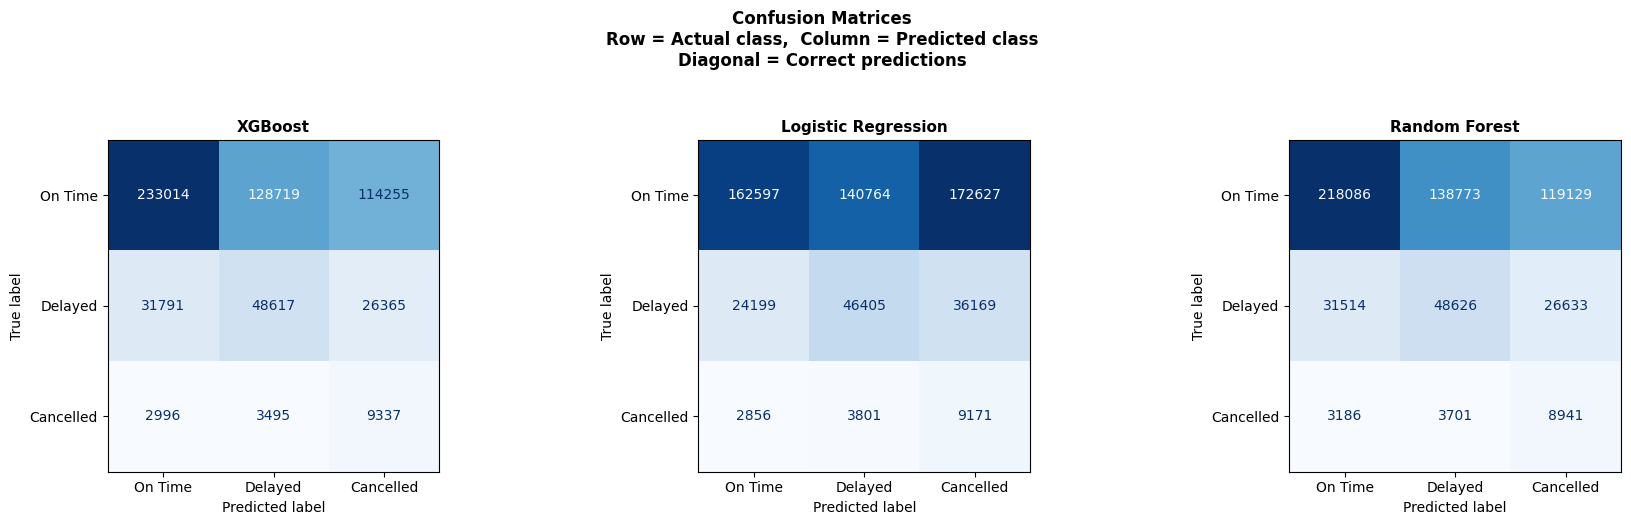

In [ ]:
# Confusion Matrix
num_models = len(all_models)
fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))
if num_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, all_models.items()):
    y_pred = model.predict(x_test_ready)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['On Time', 'Delayed', 'Cancelled']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle(
    'Confusion Matrices\n'
    'Row = Actual class,  Column = Predicted class\n'
    'Diagonal = Correct predictions',
    fontsize=12, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.show()